# Feature Importance Consistency Analysis

## Research Objective

This experiment evaluates whether the predictive importance of features remains
consistent across different sequential data windows.

Feature importance consistency is an important component of feature reliability.
A feature that is highly important in one window but substantially changes its
importance in another window may indicate changing predictive behavior.

This experiment uses Random Forest feature importance to:

1. Train models across sequential data windows.
2. Measure feature importance within each window.
3. Compare feature importance rankings across windows.
4. Quantify consistency using rank correlation.

The analysis is performed on the Loan Prediction dataset.

Note:
The Loan Prediction dataset does not contain a genuine temporal variable.
Therefore, the windows represent sequential sample windows rather than true
time-based periods.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")

In [2]:
loan_df = pd.read_csv("../datasets/loan_data_set.csv")

print("Dataset shape:", loan_df.shape)

loan_df.head()

Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Define target and features

In [3]:
loan_target = "Loan_Status"

loan_num_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

print("Target:", loan_target)
print("Features:", loan_num_cols)

Target: Loan_Status
Features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


### Prepare the target

In [4]:
loan_model_df = loan_df[loan_num_cols + [loan_target]].copy()

loan_model_df[loan_target] = (
    loan_model_df[loan_target]
    .map({"Y": 1, "N": 0})
)

print(loan_model_df[loan_target].value_counts(dropna=False))

Loan_Status
1    422
0    192
Name: count, dtype: int64


### Create the five sequential windows

In [5]:
window_indices = np.array_split(
    np.arange(len(loan_model_df)),
    5
)

windows = [
    loan_model_df.iloc[idx].copy()
    for idx in window_indices
]

print("Number of windows:", len(windows))
print("Window sizes:", [len(w) for w in windows])

Number of windows: 5
Window sizes: [123, 123, 123, 123, 122]


### Train Random Forest for each window

In [6]:
feature_importance_results = []

for window_id, window_data in enumerate(windows, start=1):

    X = window_data[loan_num_cols]
    y = window_data[loan_target]

    # Handle missing values
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    # Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    rf_model.fit(X_imputed, y)

    # Extract feature importance
    for feature, importance in zip(
        loan_num_cols,
        rf_model.feature_importances_
    ):

        feature_importance_results.append({
            "Window": window_id,
            "Feature": feature,
            "Importance": importance
        })

In [7]:
importance_df = pd.DataFrame(feature_importance_results)

importance_df.head(20)

,Window,Feature,Importance
0,1,ApplicantIncome,0.310426
1,1,CoapplicantIncome,0.168908
2,1,LoanAmount,0.251126
3,1,Loan_Amount_Term,0.046410
4,1,Credit_History,0.223130
5,2,ApplicantIncome,0.308868
6,2,CoapplicantIncome,0.157660
7,2,LoanAmount,0.341542
8,2,Loan_Amount_Term,0.063235
9,2,Credit_History,0.128694


### Create the importance matrix

In [8]:
importance_matrix = importance_df.pivot(
    index="Feature",
    columns="Window",
    values="Importance"
)

importance_matrix

Window,1,2,3,4,5
Feature,,,,,
ApplicantIncome,0.310426,0.308868,0.329719,0.258859,0.284384
CoapplicantIncome,0.168908,0.157660,0.162628,0.118663,0.159889
Credit_History,0.223130,0.128694,0.172999,0.315624,0.258280
LoanAmount,0.251126,0.341542,0.264249,0.281886,0.237941
Loan_Amount_Term,0.046410,0.063235,0.070406,0.024968,0.059506


### Visualize importance across windows

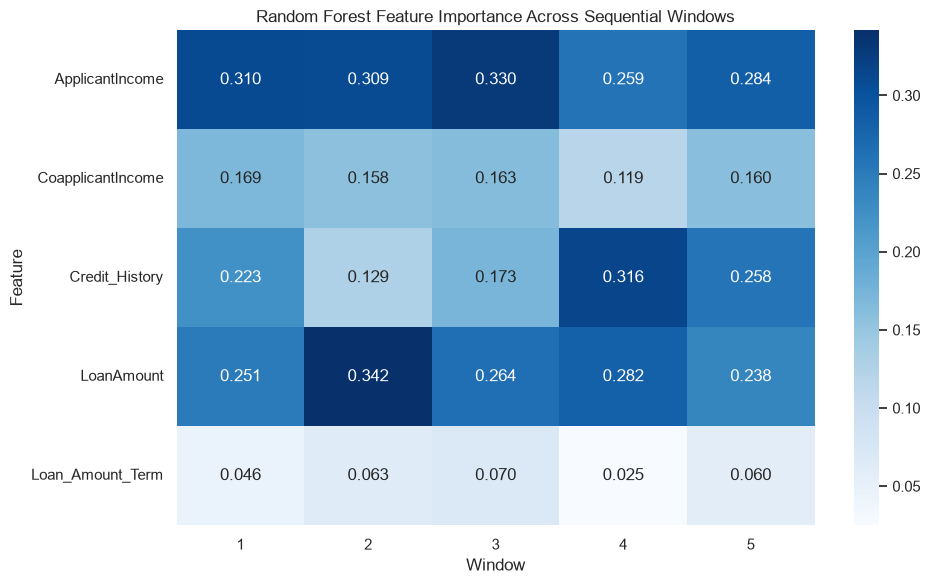

In [9]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    importance_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Random Forest Feature Importance Across Sequential Windows")
plt.xlabel("Window")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Convert importance into rankings

In [10]:
importance_ranks = importance_df.copy()

importance_ranks["Rank"] = (
    importance_ranks
    .groupby("Window")["Importance"]
    .rank(
        ascending=False,
        method="min"
    )
)

importance_ranks.head(20)

,Window,Feature,Importance,Rank
0,1,ApplicantIncome,0.310426,1.0
1,1,CoapplicantIncome,0.168908,4.0
2,1,LoanAmount,0.251126,2.0
3,1,Loan_Amount_Term,0.046410,5.0
4,1,Credit_History,0.223130,3.0
5,2,ApplicantIncome,0.308868,2.0
6,2,CoapplicantIncome,0.157660,3.0
7,2,LoanAmount,0.341542,1.0
8,2,Loan_Amount_Term,0.063235,5.0
9,2,Credit_History,0.128694,4.0


### Create ranking matrix

In [11]:
rank_matrix = importance_ranks.pivot(
    index="Feature",
    columns="Window",
    values="Rank"
)

rank_matrix

Window,1,2,3,4,5
Feature,,,,,
ApplicantIncome,1.0,2.0,1.0,3.0,1.0
CoapplicantIncome,4.0,3.0,4.0,4.0,4.0
Credit_History,3.0,4.0,3.0,1.0,2.0
LoanAmount,2.0,1.0,2.0,2.0,3.0
Loan_Amount_Term,5.0,5.0,5.0,5.0,5.0


### Rank correlation

In [12]:
rank_correlation_results = []

window_numbers = sorted(rank_matrix.columns)

for i in range(len(window_numbers)):

    for j in range(i + 1, len(window_numbers)):

        w1 = window_numbers[i]
        w2 = window_numbers[j]

        rho, p_value = spearmanr(
            rank_matrix[w1],
            rank_matrix[w2]
        )

        rank_correlation_results.append({
            "Window_1": w1,
            "Window_2": w2,
            "Spearman_Rho": rho,
            "P_Value": p_value
        })

rank_correlation_df = pd.DataFrame(
    rank_correlation_results
)

rank_correlation_df

,Window_1,Window_2,Spearman_Rho,P_Value
0,1,2,0.8,1.040880e-01
1,1,3,1.0,1.404265e-24
2,1,4,0.6,2.847570e-01
3,1,5,0.9,3.738607e-02
4,2,3,0.8,1.040880e-01
5,2,4,0.4,5.046316e-01
6,2,5,0.5,3.910022e-01
7,3,4,0.6,2.847570e-01
8,3,5,0.9,3.738607e-02
9,4,5,0.7,1.881204e-01


### Overall importance consistency

In [13]:
importance_consistency_score = (
    rank_correlation_df["Spearman_Rho"].mean()
)

print(
    "Overall Importance Consistency Score:",
    round(importance_consistency_score, 4)
)

Overall Importance Consistency Score: 0.72


### Feature-wise importance variation

In [14]:
feature_importance_summary = (
    importance_df
    .groupby("Feature")["Importance"]
    .agg(
        Mean_Importance="mean",
        Std_Importance="std",
        Min_Importance="min",
        Max_Importance="max"
    )
    .reset_index()
)

feature_importance_summary

,Feature,Mean_Importance,Std_Importance,Min_Importance,Max_Importance
0,ApplicantIncome,0.298451,0.027363,0.258859,0.329719
1,CoapplicantIncome,0.153550,0.019953,0.118663,0.168908
2,Credit_History,0.219745,0.072741,0.128694,0.315624
3,LoanAmount,0.275349,0.040415,0.237941,0.341542
4,Loan_Amount_Term,0.052905,0.017883,0.024968,0.070406


In [15]:
feature_importance_summary["Importance_CV"] = (
    feature_importance_summary["Std_Importance"]
    /
    feature_importance_summary["Mean_Importance"].abs()
)

feature_importance_summary.sort_values(
    "Importance_CV"
)

,Feature,Mean_Importance,Std_Importance,Min_Importance,Max_Importance,Importance_CV
0,ApplicantIncome,0.298451,0.027363,0.258859,0.329719,0.091684
1,CoapplicantIncome,0.153550,0.019953,0.118663,0.168908,0.129944
3,LoanAmount,0.275349,0.040415,0.237941,0.341542,0.146779
2,Credit_History,0.219745,0.072741,0.128694,0.315624,0.331022
4,Loan_Amount_Term,0.052905,0.017883,0.024968,0.070406,0.338025


In [16]:
importance_df.head(20)

,Window,Feature,Importance
0,1,ApplicantIncome,0.310426
1,1,CoapplicantIncome,0.168908
2,1,LoanAmount,0.251126
3,1,Loan_Amount_Term,0.046410
4,1,Credit_History,0.223130
5,2,ApplicantIncome,0.308868
6,2,CoapplicantIncome,0.157660
7,2,LoanAmount,0.341542
8,2,Loan_Amount_Term,0.063235
9,2,Credit_History,0.128694


In [17]:
importance_matrix = importance_df.pivot(
    index="Feature",
    columns="Window",
    values="Importance"
)

importance_matrix

Window,1,2,3,4,5
Feature,,,,,
ApplicantIncome,0.310426,0.308868,0.329719,0.258859,0.284384
CoapplicantIncome,0.168908,0.157660,0.162628,0.118663,0.159889
Credit_History,0.223130,0.128694,0.172999,0.315624,0.258280
LoanAmount,0.251126,0.341542,0.264249,0.281886,0.237941
Loan_Amount_Term,0.046410,0.063235,0.070406,0.024968,0.059506


### create the heatmap

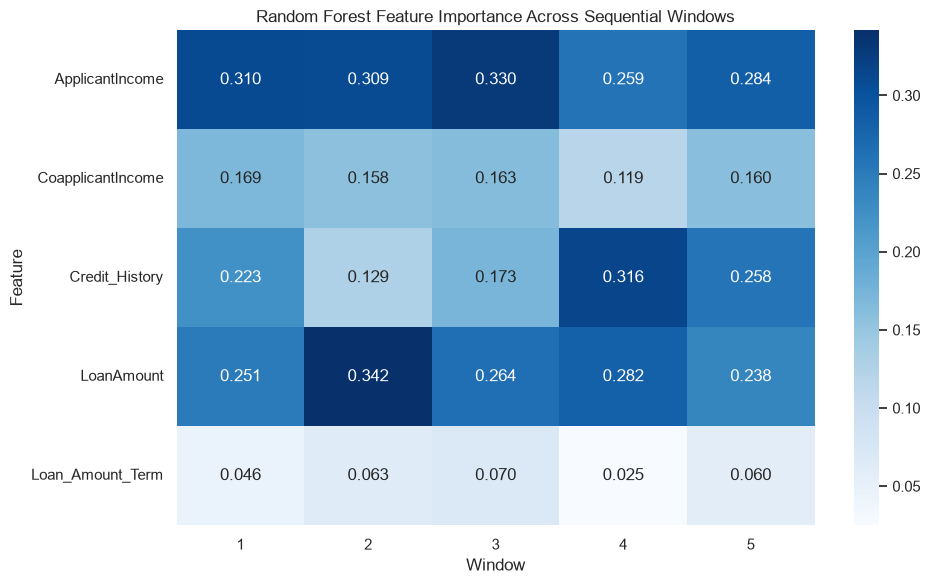

In [18]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    importance_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Random Forest Feature Importance Across Sequential Windows")
plt.xlabel("Window")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Feature Importance Ranking

In [19]:
importance_ranks = importance_df.copy()

importance_ranks["Rank"] = (
    importance_ranks
    .groupby("Window")["Importance"]
    .rank(
        ascending=False,
        method="min"
    )
)

importance_ranks

,Window,Feature,Importance,Rank
0,1,ApplicantIncome,0.310426,1.0
1,1,CoapplicantIncome,0.168908,4.0
2,1,LoanAmount,0.251126,2.0
3,1,Loan_Amount_Term,0.046410,5.0
4,1,Credit_History,0.223130,3.0
5,2,ApplicantIncome,0.308868,2.0
6,2,CoapplicantIncome,0.157660,3.0
7,2,LoanAmount,0.341542,1.0
8,2,Loan_Amount_Term,0.063235,5.0
9,2,Credit_History,0.128694,4.0


### Create the ranking matrix

In [20]:
rank_matrix = importance_ranks.pivot(
    index="Feature",
    columns="Window",
    values="Rank"
)

rank_matrix

Window,1,2,3,4,5
Feature,,,,,
ApplicantIncome,1.0,2.0,1.0,3.0,1.0
CoapplicantIncome,4.0,3.0,4.0,4.0,4.0
Credit_History,3.0,4.0,3.0,1.0,2.0
LoanAmount,2.0,1.0,2.0,2.0,3.0
Loan_Amount_Term,5.0,5.0,5.0,5.0,5.0


### Spearman Rank Correlation

In [21]:
rank_correlation_results = []

window_numbers = sorted(rank_matrix.columns)

for i in range(len(window_numbers)):

    for j in range(i + 1, len(window_numbers)):

        w1 = window_numbers[i]
        w2 = window_numbers[j]

        rho, p_value = spearmanr(
            rank_matrix[w1],
            rank_matrix[w2]
        )

        rank_correlation_results.append({
            "Window_1": w1,
            "Window_2": w2,
            "Spearman_Rho": rho,
            "P_Value": p_value
        })

rank_correlation_df = pd.DataFrame(
    rank_correlation_results
)

rank_correlation_df

,Window_1,Window_2,Spearman_Rho,P_Value
0,1,2,0.8,1.040880e-01
1,1,3,1.0,1.404265e-24
2,1,4,0.6,2.847570e-01
3,1,5,0.9,3.738607e-02
4,2,3,0.8,1.040880e-01
5,2,4,0.4,5.046316e-01
6,2,5,0.5,3.910022e-01
7,3,4,0.6,2.847570e-01
8,3,5,0.9,3.738607e-02
9,4,5,0.7,1.881204e-01


### Now we need feature-level consistency

In [22]:
feature_importance_summary = (
    importance_df
    .groupby("Feature")["Importance"]
    .agg(
        Mean_Importance="mean",
        Std_Importance="std",
        Min_Importance="min",
        Max_Importance="max"
    )
    .reset_index()
)

feature_importance_summary

,Feature,Mean_Importance,Std_Importance,Min_Importance,Max_Importance
0,ApplicantIncome,0.298451,0.027363,0.258859,0.329719
1,CoapplicantIncome,0.153550,0.019953,0.118663,0.168908
2,Credit_History,0.219745,0.072741,0.128694,0.315624
3,LoanAmount,0.275349,0.040415,0.237941,0.341542
4,Loan_Amount_Term,0.052905,0.017883,0.024968,0.070406


In [23]:
feature_importance_summary["Importance_CV"] = (
    feature_importance_summary["Std_Importance"]
    /
    feature_importance_summary["Mean_Importance"].abs()
)

feature_importance_summary.sort_values(
    "Importance_CV"
)

,Feature,Mean_Importance,Std_Importance,Min_Importance,Max_Importance,Importance_CV
0,ApplicantIncome,0.298451,0.027363,0.258859,0.329719,0.091684
1,CoapplicantIncome,0.153550,0.019953,0.118663,0.168908,0.129944
3,LoanAmount,0.275349,0.040415,0.237941,0.341542,0.146779
2,Credit_History,0.219745,0.072741,0.128694,0.315624,0.331022
4,Loan_Amount_Term,0.052905,0.017883,0.024968,0.070406,0.338025


### visualize importance consistency

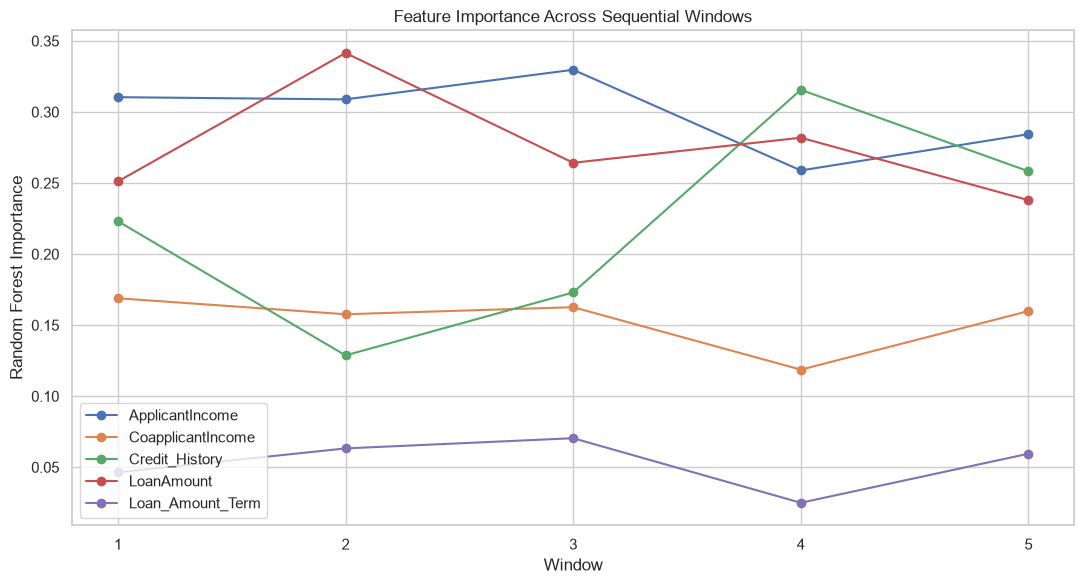

In [24]:
plt.figure(figsize=(11, 6))

for feature in importance_matrix.index:
    plt.plot(
        importance_matrix.columns,
        importance_matrix.loc[feature],
        marker="o",
        label=feature
    )

plt.title("Feature Importance Across Sequential Windows")
plt.xlabel("Window")
plt.ylabel("Random Forest Importance")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.tight_layout()
plt.show()

### create the overall consistency result

In [25]:
importance_consistency_score = (
    rank_correlation_df["Spearman_Rho"].mean()
)

print(
    "Mean Pairwise Spearman Rank Correlation:",
    round(importance_consistency_score, 4)
)

Mean Pairwise Spearman Rank Correlation: 0.72


### Preliminary Observation

Random Forest feature importance was evaluated across five sequential
sample windows. The mean pairwise Spearman rank correlation was 0.72,
indicating moderately strong consistency in feature rankings across
windows.

ApplicantIncome showed relatively low importance variation (Importance
CV = 0.092), while Credit_History and Loan_Amount_Term showed higher
relative variation. However, these results are treated as preliminary
evidence of importance consistency rather than a final reliability
classification.

Further SHAP-based analysis will be performed to validate whether the
observed importance patterns are consistent using an independent
model-attribution approach.

# SHAP Importance Consistency

In [26]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


### Calculate SHAP importance

In [27]:
shap_importance_results = []

for window_id, window_data in enumerate(windows, start=1):

    X = window_data[loan_num_cols]
    y = window_data[loan_target]

    # Impute missing values
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    # Convert back to DataFrame so feature names are preserved
    X_imputed_df = pd.DataFrame(
        X_imputed,
        columns=loan_num_cols,
        index=X.index
    )

    # Train Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    rf_model.fit(X_imputed_df, y)

    # SHAP explainer
    explainer = shap.TreeExplainer(rf_model)

    shap_values = explainer.shap_values(X_imputed_df)

In [28]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(122, 5, 2)


### Extract SHAP importance

In [29]:
# Extract SHAP values for the positive class
shap_class1 = shap_values[:, :, 1]

# Mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_class1).mean(axis=0)

# Normalize so feature importances sum to 1
shap_importance = mean_abs_shap / mean_abs_shap.sum()

# Store results
shap_importance_results.append(shap_importance)

print(f"Window {window_id} SHAP importance:")
print(
    pd.Series(
        shap_importance,
        index=loan_num_cols
    ).sort_values(ascending=False)
)

Window 5 SHAP importance:
Credit_History       0.427009
ApplicantIncome      0.202820
LoanAmount           0.169386
CoapplicantIncome    0.130086
Loan_Amount_Term     0.070698
dtype: float64


### Run SHAP across all five windows

In [30]:
shap_importance_results = []

for window_id, window_data in enumerate(windows, start=1):

    X = window_data[loan_num_cols]
    y = window_data[loan_target]

    # Median imputation
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    X_imputed_df = pd.DataFrame(
        X_imputed,
        columns=loan_num_cols,
        index=X.index
    )

    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    rf_model.fit(X_imputed_df, y)

    # SHAP Tree Explainer
    explainer = shap.TreeExplainer(rf_model)

    shap_values = explainer.shap_values(X_imputed_df)

    # SHAP 0.51.0 returns:
    # (n_samples, n_features, n_classes)
    shap_class1 = shap_values[:, :, 1]

    # Mean absolute SHAP importance
    mean_abs_shap = np.abs(shap_class1).mean(axis=0)

    # Normalize
    shap_importance = mean_abs_shap / mean_abs_shap.sum()

    shap_importance_results.append(shap_importance)

# Convert to DataFrame
shap_importance_matrix = pd.DataFrame(
    shap_importance_results,
    index=[f"Window {i}" for i in range(1, 6)],
    columns=loan_num_cols
)

shap_importance_matrix

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Window 1,0.242998,0.144427,0.159700,0.062573,0.390301
Window 2,0.224311,0.158269,0.294540,0.067599,0.255281
Window 3,0.247700,0.213097,0.174591,0.067243,0.297369
Window 4,0.171926,0.083710,0.265467,0.021001,0.457895
Window 5,0.202820,0.130086,0.169386,0.070698,0.427009


### SHAP ranking consistency

In [31]:
# Rank SHAP importance within each window

shap_rank_matrix = shap_importance_matrix.rank(
    axis=1,
    ascending=False,
    method="min"
)

shap_rank_matrix

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Window 1,2.0,4.0,3.0,5.0,1.0
Window 2,3.0,4.0,1.0,5.0,2.0
Window 3,2.0,3.0,4.0,5.0,1.0
Window 4,3.0,4.0,2.0,5.0,1.0
Window 5,2.0,4.0,3.0,5.0,1.0


### Pairwise Spearman rank correlation

In [32]:
# Pairwise Spearman rank correlations

shap_rank_correlations = []

for i in range(len(shap_rank_matrix)):
    for j in range(i + 1, len(shap_rank_matrix)):

        rho, p_value = spearmanr(
            shap_rank_matrix.iloc[i],
            shap_rank_matrix.iloc[j]
        )

        shap_rank_correlations.append({
            "Window 1": f"Window {i + 1}",
            "Window 2": f"Window {j + 1}",
            "Spearman_Rho": rho,
            "P_Value": p_value
        })

shap_rank_corr_df = pd.DataFrame(shap_rank_correlations)

shap_rank_corr_df

,Window 1,Window 2,Spearman_Rho,P_Value
0,Window 1,Window 2,0.7,1.881204e-01
1,Window 1,Window 3,0.9,3.738607e-02
2,Window 1,Window 4,0.9,3.738607e-02
3,Window 1,Window 5,1.0,1.404265e-24
4,Window 2,Window 3,0.4,5.046316e-01
5,Window 2,Window 4,0.9,3.738607e-02
6,Window 2,Window 5,0.7,1.881204e-01
7,Window 3,Window 4,0.7,1.881204e-01
8,Window 3,Window 5,0.9,3.738607e-02
9,Window 4,Window 5,0.9,3.738607e-02


### Mean SHAP consistency

In [33]:
mean_shap_rank_correlation = shap_rank_corr_df["Spearman_Rho"].mean()

print(
    f"Mean pairwise SHAP rank correlation: "
    f"{mean_shap_rank_correlation:.3f}"
)

Mean pairwise SHAP rank correlation: 0.800


### Compare Random Forest and SHAP importance

In [34]:
# Mean SHAP importance across all windows

mean_shap_importance = shap_importance_matrix.mean(axis=0)

shap_summary = pd.DataFrame({
    "Feature": loan_num_cols,
    "Mean_SHAP_Importance": mean_shap_importance.values
})

shap_summary.sort_values(
    "Mean_SHAP_Importance",
    ascending=False
)

,Feature,Mean_SHAP_Importance
4,Credit_History,0.365571
0,ApplicantIncome,0.217951
2,LoanAmount,0.212737
1,CoapplicantIncome,0.145918
3,Loan_Amount_Term,0.057823


In [43]:
# Mean Random Forest importance across all windows

mean_rf_importance = importance_matrix.mean(axis=1)

rf_summary = pd.DataFrame({
    "Feature": loan_num_cols,
    "Mean_RF_Importance": mean_rf_importance.values
})

rf_summary.sort_values(
    "Mean_RF_Importance",
    ascending=False
)

,Feature,Mean_RF_Importance
0,ApplicantIncome,0.298451
3,Loan_Amount_Term,0.275349
2,LoanAmount,0.219745
1,CoapplicantIncome,0.153550
4,Credit_History,0.052905


In [44]:
# Combine Random Forest and SHAP importance

importance_comparison = pd.DataFrame({
    "Feature": loan_num_cols,
    "Mean_RF_Importance": mean_rf_importance.values,
    "Mean_SHAP_Importance": mean_shap_importance.values
})

importance_comparison = importance_comparison.sort_values(
    "Mean_RF_Importance",
    ascending=False
)

importance_comparison

,Feature,Mean_RF_Importance,Mean_SHAP_Importance
0,ApplicantIncome,0.298451,0.217951
3,Loan_Amount_Term,0.275349,0.057823
2,LoanAmount,0.219745,0.212737
1,CoapplicantIncome,0.153550,0.145918
4,Credit_History,0.052905,0.365571


### RF vs SHAP rank agreement

In [45]:
# Calculate feature rankings

importance_comparison["RF_Rank"] = (
    importance_comparison["Mean_RF_Importance"]
    .rank(ascending=False, method="min")
)

importance_comparison["SHAP_Rank"] = (
    importance_comparison["Mean_SHAP_Importance"]
    .rank(ascending=False, method="min")
)

# Spearman correlation between the two importance rankings

rf_shap_rho, rf_shap_p = spearmanr(
    importance_comparison["RF_Rank"],
    importance_comparison["SHAP_Rank"]
)

print(f"RF vs SHAP rank correlation: {rf_shap_rho:.3f}")
print(f"P-value: {rf_shap_p:.4f}")

importance_comparison

RF vs SHAP rank correlation: -0.300
P-value: 0.6238


,Feature,Mean_RF_Importance,Mean_SHAP_Importance,RF_Rank,SHAP_Rank
0,ApplicantIncome,0.298451,0.217951,1.0,2.0
3,Loan_Amount_Term,0.275349,0.057823,2.0,5.0
2,LoanAmount,0.219745,0.212737,3.0,3.0
1,CoapplicantIncome,0.153550,0.145918,4.0,4.0
4,Credit_History,0.052905,0.365571,5.0,1.0


### Correct RF vs SHAP comparison

In [46]:
# Correct mean Random Forest importance across the five windows

mean_rf_importance = importance_matrix.mean(axis=1)

# Mean SHAP importance across the five windows
mean_shap_importance = shap_importance_matrix.mean(axis=0)

# Combine both methods
importance_comparison = pd.DataFrame({
    "Feature": loan_num_cols,
    "Mean_RF_Importance": mean_rf_importance.values,
    "Mean_SHAP_Importance": mean_shap_importance.values
})

# Rank features
importance_comparison["RF_Rank"] = (
    importance_comparison["Mean_RF_Importance"]
    .rank(ascending=False, method="min")
)

importance_comparison["SHAP_Rank"] = (
    importance_comparison["Mean_SHAP_Importance"]
    .rank(ascending=False, method="min")
)

importance_comparison = importance_comparison.sort_values(
    "RF_Rank"
)

importance_comparison

,Feature,Mean_RF_Importance,Mean_SHAP_Importance,RF_Rank,SHAP_Rank
0,ApplicantIncome,0.298451,0.217951,1.0,2.0
3,Loan_Amount_Term,0.275349,0.057823,2.0,5.0
2,LoanAmount,0.219745,0.212737,3.0,3.0
1,CoapplicantIncome,0.153550,0.145918,4.0,4.0
4,Credit_History,0.052905,0.365571,5.0,1.0


In [47]:
# RF vs SHAP rank correlation

rf_shap_rho, rf_shap_p = spearmanr(
    importance_comparison["Mean_RF_Importance"],
    importance_comparison["Mean_SHAP_Importance"]
)

print(f"RF vs SHAP rank correlation: {rf_shap_rho:.3f}")
print(f"P-value: {rf_shap_p:.4f}")

RF vs SHAP rank correlation: -0.300
P-value: 0.6238


## RF vs SHAP Visualization

## Random Forest vs SHAP Feature Importance

To compare feature importance obtained from model-based Random Forest importance and SHAP-based attribution, the mean importance of each feature across the five sample windows is visualized. This comparison helps assess whether feature importance is consistent across different attribution approaches.

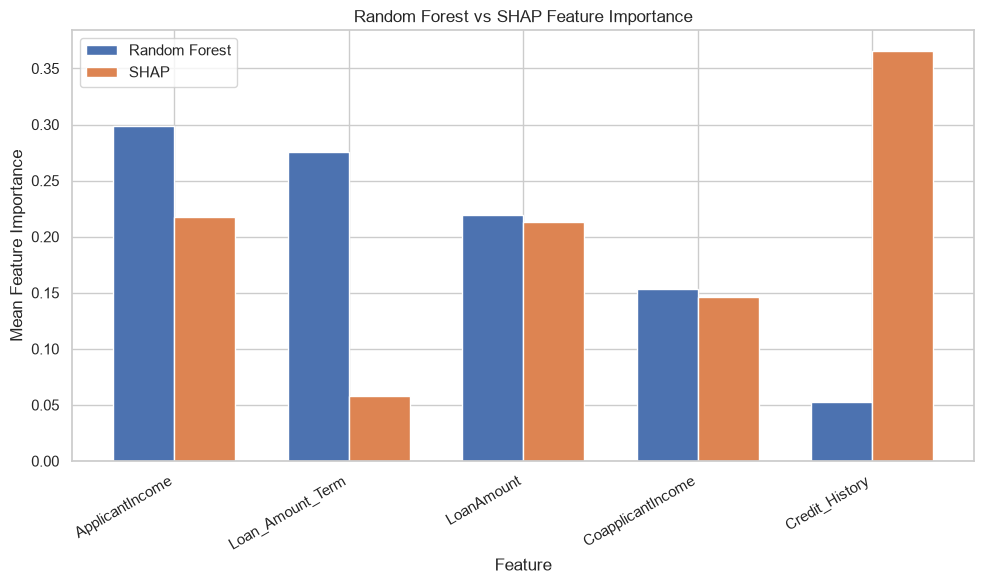

In [48]:
# Prepare data for visualization

plot_df = importance_comparison.copy()

plot_df = plot_df.sort_values(
    "Mean_RF_Importance",
    ascending=False
)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    plot_df["Mean_RF_Importance"],
    width,
    label="Random Forest"
)

plt.bar(
    x + width/2,
    plot_df["Mean_SHAP_Importance"],
    width,
    label="SHAP"
)

plt.xticks(
    x,
    plot_df["Feature"],
    rotation=30,
    ha="right"
)

plt.ylabel("Mean Feature Importance")
plt.xlabel("Feature")
plt.title("Random Forest vs SHAP Feature Importance")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

This notebook evaluated feature importance consistency in the Loan Prediction dataset across five sequential sample windows using two complementary approaches: Random Forest feature importance and SHAP-based feature attribution.

The Random Forest analysis showed a mean pairwise Spearman rank correlation of 0.72 across the five windows, indicating moderately strong consistency in feature rankings. ApplicantIncome remained one of the most important features across the windows, while Credit_History showed comparatively larger variation in its Random Forest importance. The feature-level importance variation also showed that some features were more sensitive to the sample window than others.

SHAP analysis was then performed using the same five windows to provide an independent attribution-based assessment. The mean pairwise SHAP rank correlation was 0.80, indicating relatively strong consistency in SHAP-based feature rankings across the windows. Credit_History was consistently identified as a highly important feature, while Loan_Amount_Term remained the least important feature across all five windows.

The comparison between Random Forest and SHAP revealed that feature importance depends partly on the attribution methodology. ApplicantIncome and LoanAmount showed relatively similar importance patterns under both approaches, whereas Credit_History received substantially higher importance from SHAP than from Random Forest. The RF–SHAP rank correlation was -0.30; however, this result should be interpreted cautiously because the comparison contains only five features and therefore has limited statistical power.

An important observation from the analysis is that distributional stability and predictive importance are different properties of a feature. For example, Credit_History showed relatively stable distributional behavior in the earlier distributional analysis while remaining highly important for prediction. Similarly, features showing greater distributional variation do not automatically become unimportant. Therefore, feature reliability cannot be determined from a single metric or a single importance method.

Overall, Notebook 04 demonstrates that feature importance should be evaluated across multiple sample windows and, where possible, using complementary attribution methods. Random Forest and SHAP provide different perspectives on feature contribution, and their differences highlight the importance of considering methodological sensitivity when assessing feature reliability.

These findings provide the importance-consistency component of the proposed feature reliability framework. However, they do not yet establish whether a feature is ultimately reliable or unreliable. The next stage will investigate whether differences in feature reliability are associated with changes or degradation in model performance.